Here, we compare our model performance to the psuedobulk baselines. 

For psuedobulk (to compare to RF, linear, and train mean baselines), loss is calculated after psuedobulking either by perturbation or condition (cell type x perturbation) using the mean of the sample-wise RMSE (as described in [Ahlmann-Eltze et al](https://doi.org/10.1038/s41592-025-02772-6) and the Pearson delta (used in [Ahlmann-Eltze et al](https://doi.org/10.1038/s41592-025-02772-6) and [Csendes et al](https://doi.org/10.1186/s12864-025-11600-2)). 

In [1]:
import os
import itertools
from collections import defaultdict

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats
from statsmodels.stats.multitest import multipletests

import sys
sys.path.insert(1, '../../.')
from Kang_utils import all_data


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [3]:
loss_sc = pd.read_csv(os.path.join(data_path, 'processed', '{}_scLEMBAS_model_losses.csv'.format(author)), 
                     index_col = 0)
loss_pb = pd.read_csv(os.path.join(data_path, 'processed', '{}_psuedobulk_baseline_losses.csv'.format(author)), 
                     index_col = 0)

(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col) = all_data

In [4]:
def cohens_d_paired(x, y):
    """Since models learn on the same folds, use paird"""
    x = np.asarray(x)
    y = np.asarray(y)

    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

For psuedobulk, we calculated both in full feature space and PLS space

This analsyis matches Notebook 06Bi section 1.3

In [5]:
loss_types = loss_pb.loss_type.unique()
loss_sclembas_pb = loss_sc[loss_sc.loss_type.isin(loss_types)].copy()
assert loss_sclembas_pb.model_type.nunique() == 1

loss_pb = pd.concat([loss_pb, loss_sclembas_pb], axis = 0, ignore_index = True)
assert loss_pb.remove_type.nunique() == 1


loss_pb[['metric', 'grouping']] = loss_pb['loss_type'].str.split('_', expand=True)


In [6]:
metrics = ['RMSE', 'Pearson']
groupings = [pert_col, 'condition']
model_types = ['actual', 'psuedobulk_RF_baseline', 'psuedobulk_linear_baseline', 'psuedobulk_mean_baseline']
loss_pb.model_type = pd.Categorical(loss_pb.model_type, 
                                   categories = model_types, ordered = True)


model_type_labels = ['scLEMBAS', 'RF', 'Linear', 'Training Mean']
metric_labels = dict(zip(metrics, ['RMSE', 'Pearson']))
grouping_labels = dict(zip(groupings, ['Perturbation', 'Condition']))


space_map = {'feature': 'Full Feature Space', 'pca': 'PCA Space'}

In [7]:
comparisons = list(itertools.product(['actual'], model_types[1:]))
def get_stats_model(viz_df):
    
    stats_df = defaultdict(list)
    for mt1, mt2 in comparisons:
        v1 = viz_df[viz_df.model_type == mt1].loss
        v2 = viz_df[viz_df.model_type == mt2].loss

        pval = stats.wilcoxon(v1, v2, alternative = 'two-sided').pvalue
        cd = cohens_d_paired(v1, v2)

        stats_df['model_type_1'].append(mt1)
        stats_df['model_type_2'].append(mt2)
        stats_df['pval'].append(pval)
        stats_df['cohen_d'].append(cd)
    stats_df = pd.DataFrame(stats_df)
    _, q, _, _ = multipletests(stats_df.pval, method = 'fdr_bh')
    stats_df['bh_fdr'] = q
    
    return stats_df


def q_to_stars(q):
    if q <= 1e-4:
        return "****"
    elif q <= 1e-3:
        return "***"
    elif q <= 1e-2:
        return "**"
    elif q <= 1e-1:
        return "*"
    else:
        return "n.s."
               
               
def p_to_stars(p):
    if p <= 5e-5:
        return "****"
    elif p <= 5e-4:
        return "***"
    elif p <= 5e-3:
        return "**"
    elif p <= 5e-2:
        return "*"
    else:
        return "n.s."


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.5, fontsize=11):
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=lw,
            color="black",
            clip_on=False)
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=fontsize,
            color="black")

def annotate_stats_model(ax, viz_df, stats_df, comparisons,
                             pad_frac=0.05, step_frac=0.1):
    # seaborn categorical x positions
    cats = list(viz_df["model_type"].cat.categories)
    x_map = {c: i for i, c in enumerate(cats)}

    # use CURRENT axis limits for stable placement
    ylo, yhi = ax.get_ylim()
    yr = (yhi - ylo) if yhi > ylo else 1.0

    y0 = yhi + pad_frac * yr
    h = 0.02 * yr

    for k, (mt1, mt2) in enumerate(comparisons):
        row = stats_df[
            (stats_df.model_type_1 == mt1) &
            (stats_df.model_type_2 == mt2)
        ].iloc[0]

        stars = q_to_stars(float(row["bh_fdr"]))
        d = float(row["cohen_d"])
        label = "{}, Cohen's d: {:.1f}".format(stars, d)

        x1, x2 = x_map[mt1], x_map[mt2]
        y = y0 + k * step_frac * yr

        add_sig_bracket(ax, x1, x2, y=y, h=h, text=label)

    # only extend top of y-axis; keep bottom unchanged
    ax.set_ylim(ylo, y0 + (len(comparisons) + 1) * (step_frac*0.8) * yr)


In [8]:
stats_df_all = []

## Full Feature Space


In [9]:
space = 'feature'
space_mask = (loss_pb.space == space)

''

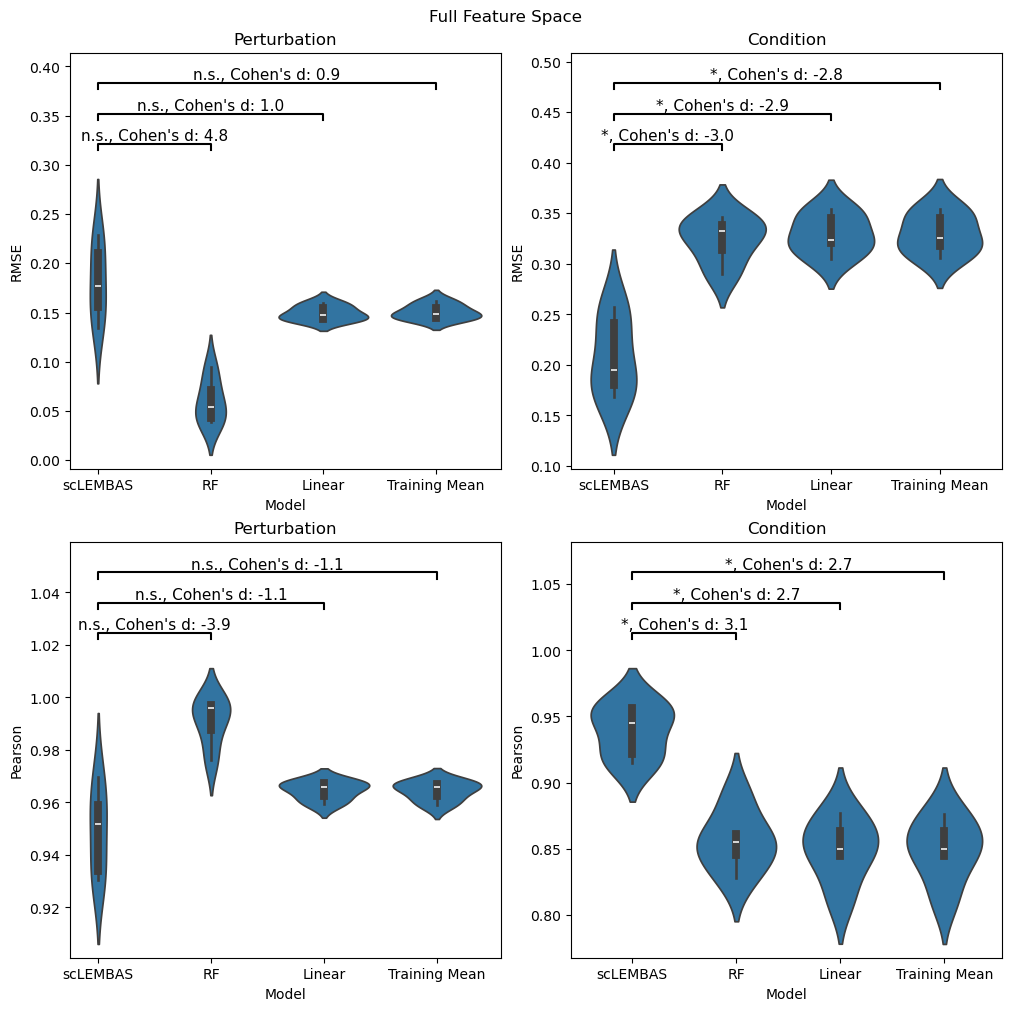

In [10]:
nrows, ncols = len(metrics), len(groupings)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5, nrows*5), constrained_layout = True)


for (i, metric) in enumerate(metrics):
    for (j, grouping) in enumerate(groupings):
        metric_mask = (loss_pb.metric == metric)
        grouping_mask = (loss_pb.grouping == grouping)

        viz_df = loss_pb[space_mask & metric_mask & grouping_mask]
        stats_df = get_stats_model(viz_df)
        
        sns.violinplot(data = viz_df, x = 'model_type', y = 'loss', order = model_types, ax = ax[i,j])
        
        ax[i, j].set_xticks(range(len(model_type_labels)))
        ax[i, j].set_xticklabels(model_type_labels)
        
        ax[i,j].set_ylabel(metric_labels[metric])
        ax[i,j].set_xlabel('Model')
        ax[i,j].set_title(grouping_labels[grouping])
        
        
        annotate_stats_model(
            ax=ax[i, j],
            viz_df=viz_df,
            stats_df=stats_df,
            comparisons=comparisons
        )
        
        stats_df['metric'] = metric
        stats_df['grouping'] = grouping
        stats_df['space'] = space
        stats_df_all.append(stats_df)
        
        
fig.suptitle(space_map[space])
;

In the full feature space, we see that scLEMBAS often performs worse than baselines when psuedo-bulked by perturbaiton. However, when psuedobulked by perturbation condition, this does not tend to be the case. 

In [11]:
def get_stats_grouping(viz_df):
    """
    viz_df is subset to ONE model_type + ONE metric.
    Compare loss between groupings (ligand vs condition).
    """
    v1 = viz_df[viz_df.grouping == pert_col].loss
    v2 = viz_df[viz_df.grouping == 'condition'].loss

    pval = stats.mannwhitneyu(v1, v2, alternative='two-sided').pvalue
    cd   = cohens_d_paired(v1, v2)

    stats_df = pd.DataFrame({
        'grouping_1': [pert_col],
        'grouping_2': ['condition'],
        'pval': [pval],
        'cohen_d': [cd],
    })

#     _, q, _, _ = multipletests(stats_df.pval, method='fdr_bh')
#     stats_df['bh_fdr'] = q
    return stats_df

def add_sig_bracket_grouping(ax, x1, x2, y, h, text, lw=1.5, fontsize=11):
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=lw,
            color="black",
            clip_on=False)
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=fontsize,
            color="black")

def annotate_stats_grouping(ax, viz_df, stats_df,
                   g1=pert_col, g2='condition',
                   x_order=(pert_col, 'condition'),
                   pad_frac=0.05, bottom_pad_frac=0.03):
    """
    No hue here. Bracket goes from tick center 0 -> 1 (within this panel).
    Robust y-lims based on data.
    """
    x_map = {x: i for i, x in enumerate(x_order)}
    x1, x2 = x_map[g1], x_map[g2]

    y_data_min = np.nanmin(viz_df["loss"].values)
    y_data_max = np.nanmax(viz_df["loss"].values)

    ylo_cur, yhi_cur = ax.get_ylim()
    yr = (y_data_max - y_data_min) if (y_data_max > y_data_min) else (yhi_cur - ylo_cur if yhi_cur > ylo_cur else 1.0)

    # ensure we never clip below the actual data
    ylo = min(ylo_cur, y_data_min - bottom_pad_frac * yr)
    yhi_base = max(yhi_cur, y_data_max)

    y0 = yhi_base + pad_frac * yr
    h  = 0.02 * yr

    row = stats_df.iloc[0]
    stars = p_to_stars(float(row["pval"]))
    d = float(row["cohen_d"])
    label = "{}, Cohen's d: {:.3f}".format(stars, d)

    add_sig_bracket_grouping(ax, x1, x2, y=y0, h=h, text=label)

    # expand top to fit bracket; keep bottom robust
    ax.set_ylim(ylo, y0 + 0.12 * yr)

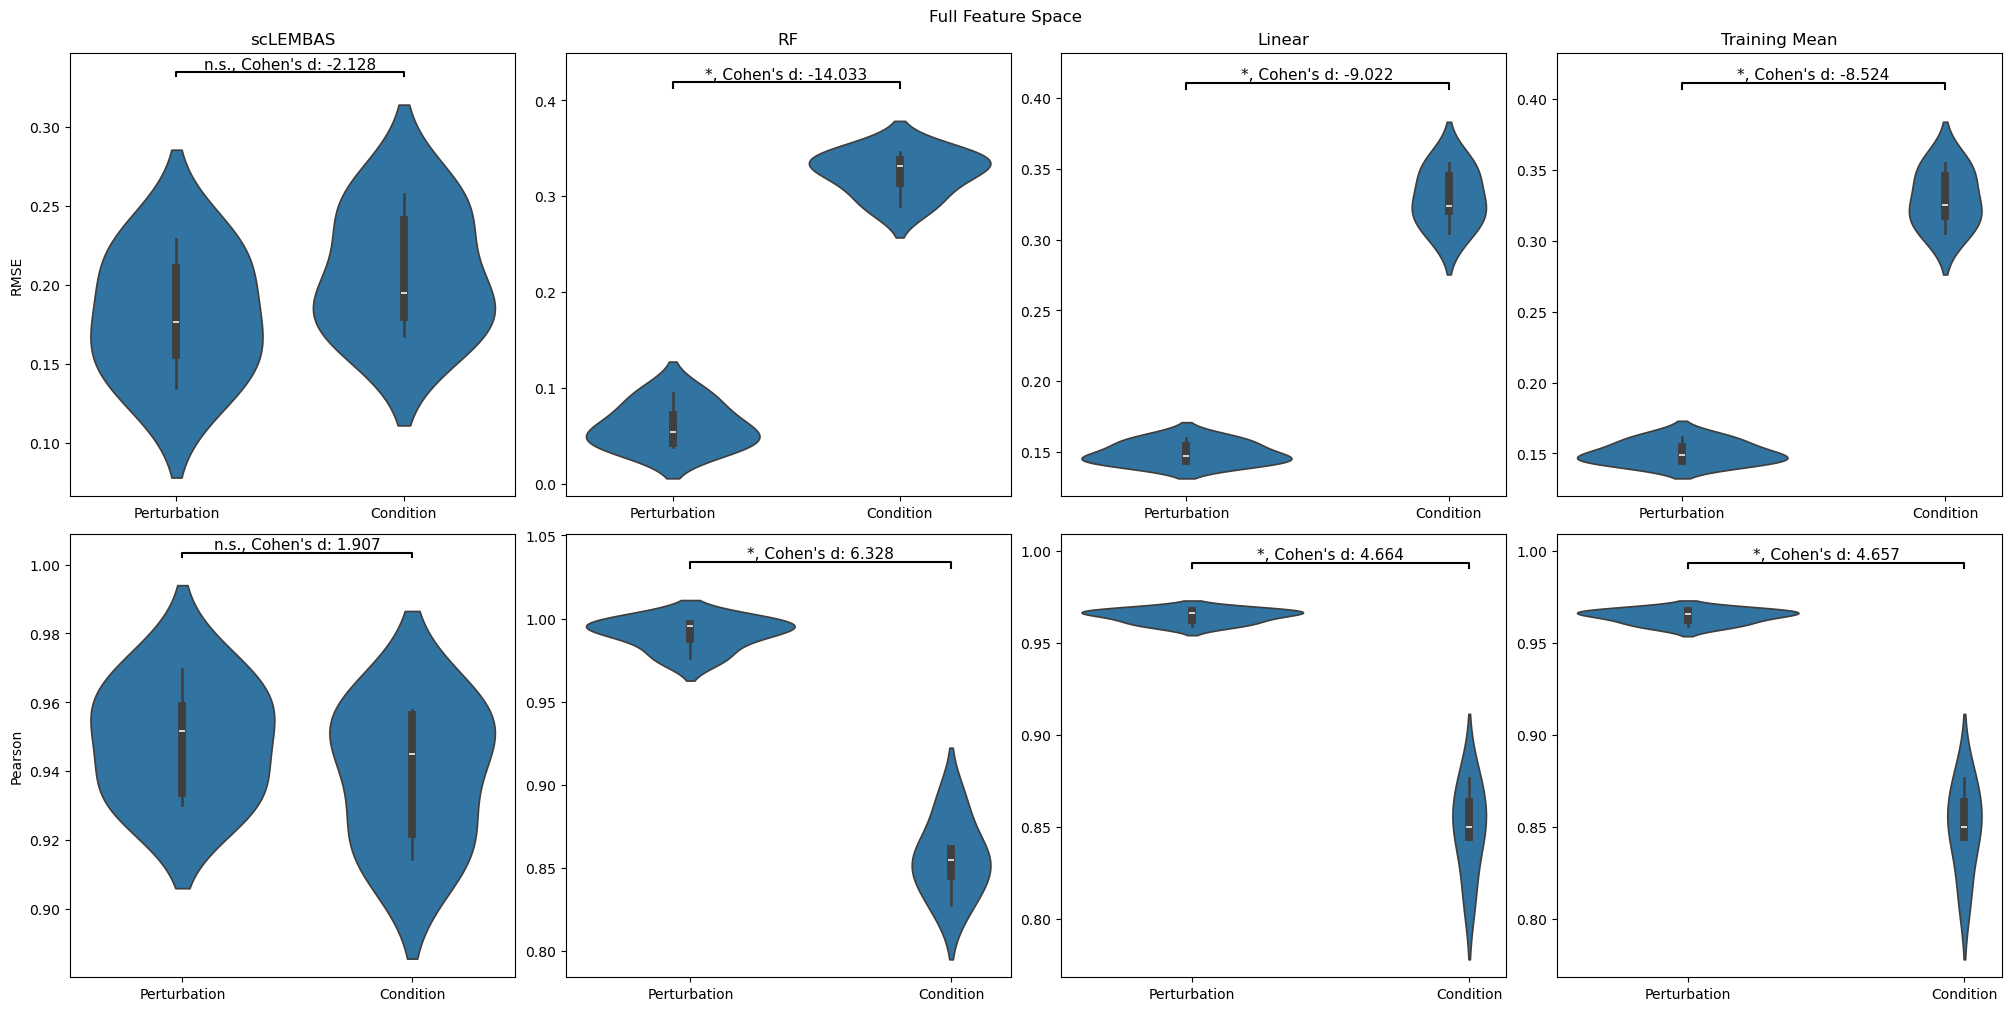

In [12]:
nrows, ncols = len(metrics), len(model_types)
fig, ax = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols*5, nrows*5),
    constrained_layout=True
)
ax = np.atleast_2d(ax)
for i, metric in enumerate(metrics):
    for j, mt in enumerate(model_types):

        metric_mask = (loss_pb.metric == metric)
        mt_mask = (loss_pb.model_type == mt)

        viz_df = loss_pb[space_mask & metric_mask & mt_mask].copy()

        # violin: x=grouping
        sns.violinplot(
            data=viz_df,
            x='grouping',
            y='loss',
            order=groupings,
            ax=ax[i, j]
        )

        # fixed ticks/labels
        ax[i, j].set_xticks(range(len(groupings)))
        ax[i, j].set_xticklabels([grouping_labels[g] for g in groupings])

        # titles: top row shows model name (column headers)
        if i == 0:
            ax[i, j].set_title(model_type_labels[j])
        else:
            ax[i, j].set_title("")

        # y labels: leftmost col shows metric name (row headers)
        if j == 0:
            ax[i, j].set_ylabel(metric_labels[metric])
        else:
            ax[i, j].set_ylabel("")

        ax[i, j].set_xlabel("")

        # stats + annotation
        stats_df = get_stats_grouping(viz_df)
        annotate_stats_grouping(
            ax=ax[i, j],
            viz_df=viz_df,
            stats_df=stats_df,
            g1=pert_col,
            g2='condition',
            x_order=groupings,
            pad_frac=0.05,
            bottom_pad_frac=0.03
        )

fig.suptitle(space_map[space])
plt.show()


Here, we can see that RF and linear baselines, which are the ones that outperformed scLEMBAS by perturbation, also get worse when grouping by condition (cell type + perturbation). In contrast, scLEMBAS does not get worse. These are ofcourse simple baselines not trained on cell type, but, the goal *is* condition-specific performance. This begins to indicate that these baselines and their corresponding assessments may not suffice. 

## PLS Space

In the visualization from Notebook 01Bi, it was not apparent that the psuedobulk baseline models outperformed scLEMBAS. Let's take a look at the loss metrics in PLS space rather than full feature space.

In [13]:
space = 'pca'
space_mask = (loss_pb.space == space)

''

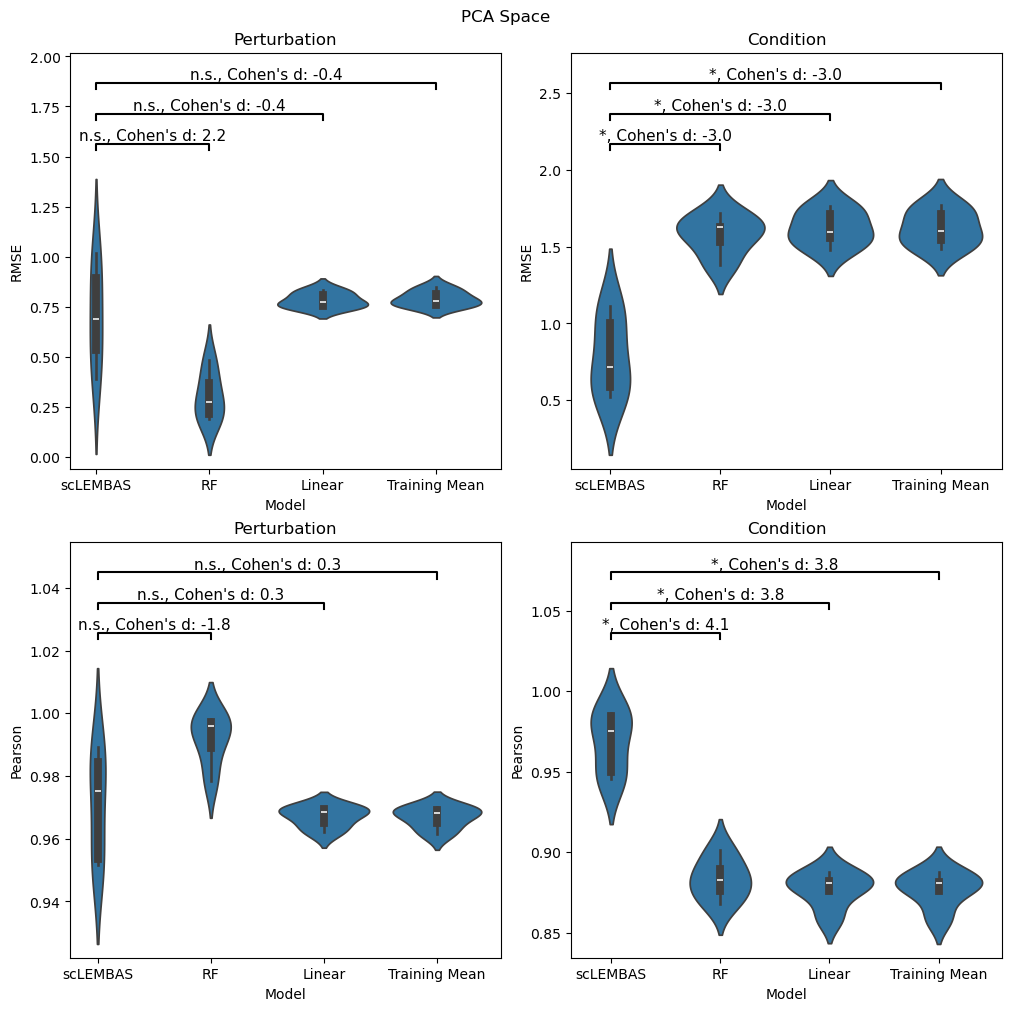

In [14]:
nrows, ncols = len(metrics), len(groupings)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5, nrows*5), constrained_layout = True)

for (i, metric) in enumerate(metrics):
    for (j, grouping) in enumerate(groupings):
        metric_mask = (loss_pb.metric == metric)
        grouping_mask = (loss_pb.grouping == grouping)

        viz_df = loss_pb[space_mask & metric_mask & grouping_mask]
        stats_df = get_stats_model(viz_df)
        
        sns.violinplot(data = viz_df, x = 'model_type', y = 'loss', order = model_types, ax = ax[i,j])
        
        ax[i, j].set_xticks(range(len(model_type_labels)))
        ax[i, j].set_xticklabels(model_type_labels)
        
        ax[i,j].set_ylabel(metric_labels[metric])
        ax[i,j].set_xlabel('Model')
        ax[i,j].set_title(grouping_labels[grouping])
        
        
        annotate_stats_model(
            ax=ax[i, j],
            viz_df=viz_df,
            stats_df=stats_df,
            comparisons=comparisons
        )
        
        stats_df['metric'] = metric
        stats_df['grouping'] = grouping
        stats_df['space'] = space
        stats_df_all.append(stats_df)
        
fig.suptitle(space_map[space])
;

In [15]:
stats_df_all = pd.concat(stats_df_all)

In [16]:
def label_cd(x):
    cd = x.iloc[0]
    metric = x.iloc[1]
    
    if metric == 'RMSE':
        if np.sign(cd) > 0:
            return 'worse'
        else:
            return 'better'
    if metric == 'Pearson':
        if np.sign(cd) > 0:
            return 'better'
        else:
            return 'worse'

In [17]:
sig_stats = stats_df_all.copy()
sig_stats['directionality'] = sig_stats[['cohen_d', 'metric']].apply(lambda x: label_cd(x), axis = 1)

sig_mask = sig_stats.bh_fdr.apply(lambda q: True if q<= 0.1 else False)
sig_stats[sig_mask][['space', 'directionality']].reset_index(drop = True)

,space,directionality
0,feature,better
1,feature,better
2,feature,better
3,feature,better
4,feature,better
5,feature,better
6,pca,better
7,pca,better
8,pca,better
9,pca,better


We can see that baseline models only significantly outperform scLEMBAS in the full feature space. 

In [18]:
feature_mask = (stats_df_all.space == 'feature')
stats_df_feature = stats_df_all[feature_mask].copy()
stats_df_pls = stats_df_all[~feature_mask].copy()


feature_cd_label = stats_df_feature[['cohen_d', 'metric']].apply(lambda x: label_cd(x), axis = 1)
pls_cd_label = stats_df_pls[['cohen_d', 'metric']].apply(lambda x: label_cd(x), axis = 1)
no_change = (feature_cd_label == pls_cd_label)
n_changes = pls_cd_label[~no_change].value_counts()

msg = 'In full feature space, scLEMBAS performs worse than baseline models in {:.1f}% comparisons.\n\n'.format(
    100*feature_cd_label.value_counts(normalize = True).worse 
)

msg += 'In PCA space, scLEMBAS performs worse than baseline models in {:.2f}% comparisons.\n\n'.format(
    100*pls_cd_label.value_counts(normalize = True).worse 
)

msg += 'Of the {} effect sizes that changed directionality from full feature to PLS space (out of {} total comparisons), {} indicate scLEMBAS improves (goes from being worse than baseline to better than baseline)\n\n'.format(
    n_changes.sum(), 
    feature_cd_label.shape[0],
    n_changes.better,
)


stats_df_feature['cd_direction'] = feature_cd_label
stats_df_pls['cd_direction'] = pls_cd_label

tot_agreement = 0
same_effect_size = defaultdict(list)
for i in range(stats_df_feature.shape[0]):
    row_feature = stats_df_feature.iloc[i, :]
    row_pls = stats_df_pls.iloc[i, :]
    
    cd_direction = row_feature.cd_direction
    if  cd_direction != row_pls.cd_direction:
        continue
    else:
        cd_feature = np.abs(row_feature.cohen_d)
        cd_pls = np.abs(row_pls.cohen_d)
        
        
        if cd_direction == 'worse':
            same_effect_size[cd_direction].append('improved' if cd_pls < cd_feature else 'worsened')
        elif cd_direction == 'better':
            same_effect_size[cd_direction].append('improved' if cd_pls > cd_feature else 'worsened')
        tot_agreement += 1
msg += 'Of the {} remaining comparisons that did not change directionality from feature space to PLS space, '.format(tot_agreement)
msg += '{} of {} in which scLEMBS performed worse had a mitigated (reduced difference) effect size, and '.format(same_effect_size['worse'].count('improved'), len(same_effect_size['worse']))
msg += '{} of {} in which scLEMBS performed better had an improved (larger difference) effect size,'.format(same_effect_size['better'].count('improved'), len(same_effect_size['better']))



print(msg)

assert stats_df_feature[['model_type_1', 'model_type_2', 'metric', 'grouping']].equals(stats_df_pls[['model_type_1', 'model_type_2', 'metric', 'grouping']]), 'Assumes same ordering of compar'




In full feature space, scLEMBAS performs worse than baseline models in 50.0% comparisons.

In PCA space, scLEMBAS performs worse than baseline models in 16.67% comparisons.

Of the 4 effect sizes that changed directionality from full feature to PLS space (out of 12 total comparisons), 4 indicate scLEMBAS improves (goes from being worse than baseline to better than baseline)

Of the 8 remaining comparisons that did not change directionality from feature space to PLS space, 2 of 2 in which scLEMBS performed worse had a mitigated (reduced difference) effect size, and 6 of 6 in which scLEMBS performed better had an improved (larger difference) effect size,
